# Module 8: Comparing MLP, RNN, LSTM, and GRU for Diabetes Prediction

## Learning Objectives

By the end of this module, **You** will be able to:

1. Load and preprocess a tabular dataset.
2. Understand the difference between feed-forward and recurrent neural networks.
3. Implement an MLP, RNN, LSTM, and GRU using PyTorch.
4. Train and evaluate multiple neural network architectures.
5. Compare model performance using common classification metrics.
6. Interpret the strengths and limitations of recurrent models on tabular data.

## Important Note

- The diabetes dataset used in this notebook is a **tabular dataset**, not a time-series dataset.

- RNNs, LSTMs, and GRUs are designed for sequential data. To allow a comparison, we will treat the eight input features as a short sequence of length eight.

> This transformation is useful for learning recurrent architectures, but it does **not** imply that the features are naturally ordered in time.


### Section 0: Set-up and Libraries Installation
> Have a look at the new Libraries in the following cells.

In [1]:
# Standard libraries
import time
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### Section 1: Load and Inspect the Dataset
> Download the diabetes CSV file from this [Kaggle Dataset](https://www.kaggle.com/datasets/pritsheta/diabetes-dataset) and place it in the same directory as this notebook.

Expected file:

`diabetes.csv`

The original dataset contains eight features as follows:
- Pregnancies: number of times the patient has been pregnant
- Glucose: plasma glucose concentration measured after a 2-hour oral glucose tolerance test
- BloodPressure: diastolic blood pressure (mm Hg)
- SkinThickness: triceps skinfold thickness (mm)
- Insulin: 2-hour serum insulin level (µU/ml)
- BMI: body mass index, defined as weight (kg) / height (m²)
- DiabetesPedigreeFunction: a genetic risk score based on family history of diabetes
- Age: age of the patient in years

**Target Variable:**
Outcome: binary label indicating diabetes status
- 1: diabetic
- 0: non-diabetic

In [2]:
# Load the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv("diabetes.csv")

# Display the number of rows and columns in the dataset
# This helps verify that the data has been loaded correctly
print(df.shape)

# Display the first 5 rows of the dataset
# Useful for a quick inspection of feature names and values
display(df.head())

# Display dataset metadata:
# - column names
# - non-null counts
# - data types
# This is used to assess missing values and data consistency
df.info()

## Separate Features and Target

# Construct the feature matrix X by removing the target column "Outcome"
# .values converts the DataFrame into a NumPy array for model compatibility
X = df.drop("Outcome", axis=1).values

# Extract the target vector y containing class labels (0 or 1)
y = df["Outcome"].values

# Print shapes to verify correct separation of inputs and outputs
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape) # y has shape (768,) because it is a one-dimensional array containing the 768 target labels (one per sample), not a 2D table structure.

## Train-Test Split and Feature Scaling

# Split the dataset into training and test sets
# test_size=0.2 means 20% of the data is reserved for testing
# random_state=42 ensures reproducibility of the split
# stratify=y preserves the class distribution in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,  # ensures deterministic shuffling for reproducible results
    stratify=y        # maintains proportional representation of classes in both splits
)

# Initialise a standard scaler to normalise features
# Standardisation transforms data to zero mean and unit variance
scaler = StandardScaler()

# Fit the scaler ONLY on the training data
# This computes mean and standard deviation from training set
# Prevents information leakage from test set into training process
X_train = scaler.fit_transform(X_train)

# Apply the same transformation to the test set using training statistics
# Important: we do NOT re-fit on test data to preserve evaluation integrity
X_test = scaler.transform(X_test)

# Print final shapes of processed training and test feature matrices
# Confirms that preprocessing has not altered dataset dimensions
print("Final shapes of processed training and test feature matrices:")
print(X_train.shape, X_test.shape)

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Feature matrix shape: (768, 8)
Target shape: (768,)
Final shapes of processed training and test feature matrices:
(614, 8) (154, 8)


### Section 2: Create Data for the MLP
> The MLP expects data in the form: `(batch_size, number_of_features)`

In [3]:
# Convert training features from NumPy array to PyTorch tensor
# dtype=float32 is required for compatibility with neural network layers
X_train_mlp = torch.tensor(X_train, dtype=torch.float32)

# Convert test features from NumPy array to PyTorch tensor
# Ensures the same numerical format as the training set
X_test_mlp = torch.tensor(X_test, dtype=torch.float32)

# Convert training labels to PyTorch tensor and reshape to a column vector
# .view(-1, 1) transforms shape from (N,) to (N, 1), which is required for binary classification loss functions
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

# Convert test labels to PyTorch tensor and reshape to a column vector
# Maintains consistent dimensionality with model output during evaluation
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
# Note: Evaluation goes through sklearn (numpy), not PyTorch tensors.
# Thus, won't be used as evaluate_model takes the raw numpy y_test array instead.

### Section 3: Create Data for RNN-Based Models
>The original shape is:

`(samples, 8)`

We reshape it into:

`(samples, 8, 1)`

where:
- sequence length = 8
- features per time step = 1

In [4]:
# Reshape training features for sequence-based models (e.g., RNN, LSTM, GRU)
# New shape: (samples, timesteps=8, features=1)
# Each original feature is treated as a time step in a univariate sequence
X_train_seq = torch.tensor(
    X_train.reshape(-1, 8, 1),
    dtype=torch.float32
)

# Apply the same sequence reshaping to the test set
# Ensures identical input structure during evaluation
X_test_seq = torch.tensor(
    X_test.reshape(-1, 8, 1),
    dtype=torch.float32
)

# Print tensor shape to verify correct sequence formatting
# Expected output: (number_of_samples, 8, 1)
print("Sequence training shape:", X_train_seq.shape)


# Define batch size for mini-batch gradient descent
# Controls number of samples processed before model parameter update
batch_size = 32

# Create DataLoader for MLP training
# Combines feature and label tensors into iterable batches
# shuffle=True ensures randomised batch ordering each epoch
mlp_train_loader = DataLoader(
    TensorDataset(X_train_mlp, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

# Create DataLoader for sequence model training (RNN/LSTM/GRU)
# Uses reshaped sequential input format
seq_train_loader = DataLoader(
    TensorDataset(X_train_seq, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

Sequence training shape: torch.Size([614, 8, 1])


### Section 4: Model 1: Multi-Layer Perceptron (MLP)
> Code for training MLP

In [5]:
# Define a Multilayer Perceptron (MLP) model for binary classification
# Inherits from PyTorch's base neural network module (nn.Module)
class MLP(nn.Module):

    def __init__(self):
        # Initialise the parent class (nn.Module)
        super().__init__()

        # Define the feedforward neural network architecture as a sequential stack
        self.network = nn.Sequential(
            # Input layer: maps 8 input features to 64 hidden units
            nn.Linear(8, 64),

            # Non-linear activation function to introduce non-linearity
            nn.ReLU(),

            # Dropout regularisation to reduce overfitting by randomly deactivating 30% of neurons during training
            nn.Dropout(0.3),

            # Hidden layer: reduces dimensionality from 64 to 32 neurons
            nn.Linear(64, 32),

            # Second non-linear activation function
            nn.ReLU(),

            # Output layer: maps 32 hidden units to a single output value
            # Typically used with sigmoid or BCEWithLogitsLoss for binary classification
            nn.Linear(32, 1)
        )

    # Define forward propagation through the network
    # Specifies how input data flows through layers
    def forward(self, x):
        return self.network(x)

### Section 5: Model 2: Vanilla RNN
> Code for training vanilla RNN

In [6]:
# Define a simple Recurrent Neural Network (RNN) model for binary classification
# Inherits from PyTorch base module nn.Module
class RNNModel(nn.Module):

    def __init__(self):
        # Initialise parent class
        super().__init__()

        # Define a vanilla RNN layer
        # input_size=1: each time step has a single feature
        # hidden_size=32: dimensionality of hidden state representation
        # batch_first=True: input shape is (batch_size, sequence_length, features)
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        # Fully connected layer mapping hidden representation to output logit
        # 32 → 1 for binary classification
        self.fc = nn.Linear(32, 1)

    # Define forward pass through the network
    def forward(self, x):
        # RNN returns:
        # output: all hidden states across time steps
        # hidden: final hidden state for each layer
        _, hidden = self.rnn(x)

        # Select the last hidden state from the final layer
        # hidden shape: (num_layers * num_directions, batch, hidden_size)
        # hidden[-1] extracts the final layer representation
        return self.fc(hidden[-1])

### Section 6: Model 3: LSTM
> Code for training LSTM

In [7]:
# Define a Long Short-Term Memory (LSTM) model for binary classification
# LSTM is a specialised RNN designed to capture long-range dependencies in sequential data
class LSTMModel(nn.Module):

    def __init__(self):
        # Initialise the base neural network module
        super().__init__()

        # Define the LSTM layer
        # input_size=1: each time step contains a single feature
        # hidden_size=32: dimensionality of the hidden state and cell state
        # batch_first=True: input shape is (batch_size, sequence_length, features)
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        # Fully connected layer mapping LSTM hidden representation to a single output logit
        # Used for binary classification tasks
        self.fc = nn.Linear(32, 1)

    # Define forward propagation logic
    def forward(self, x):
        # LSTM returns:
        # output: hidden states for all time steps (not used here)
        # (hidden, cell): final hidden state and cell state for each layer
        _, (hidden, _) = self.lstm(x)

        # Extract the final hidden state from the last LSTM layer
        # hidden shape: (num_layers, batch_size, hidden_size)
        return self.fc(hidden[-1])

### Section 7: Model 4: GRU
> Code for training GRU

In [8]:
# Define a Gated Recurrent Unit (GRU) model for binary classification
# GRU is a simplified variant of LSTM that uses gating mechanisms to capture sequential dependencies
class GRUModel(nn.Module):

    def __init__(self):
        # Initialise the base PyTorch neural network module
        super().__init__()

        # Define the GRU layer
        # input_size=1: each time step contains a single feature
        # hidden_size=32: dimensionality of the hidden state representation
        # batch_first=True: input tensor shape is (batch_size, sequence_length, features)
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        # Fully connected output layer mapping hidden state to a single logit
        # Used for binary classification
        self.fc = nn.Linear(32, 1)

    # Define the forward pass of the model
    def forward(self, x):
        # GRU returns:
        # output: hidden states for all time steps (not used here)
        # hidden: final hidden state for each layer
        _, hidden = self.gru(x)

        # Extract the hidden state from the last GRU layer
        # hidden shape: (num_layers, batch_size, hidden_size)
        return self.fc(hidden[-1])

### Section 8: Training Code
> Code for training function

In [9]:
# Define a generic training loop for binary classification models in PyTorch
# Supports both MLP and sequence models (RNN, LSTM, GRU)
def train_model(model, loader, epochs=50):

    # Define loss function for binary classification with raw logits
    # Internally applies sigmoid + binary cross entropy in a numerically stable way
    criterion = nn.BCEWithLogitsLoss()

    # Move model to the selected computation device (CPU or GPU)
    model.to(device)

    # Define Adam optimiser for parameter updates
    # lr controls the step size during gradient descent
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Store average loss per epoch for analysis and visualisation
    losses = []

    # Record training start time for performance measurement
    start_time = time.time()

    # Iterate over training epochs
    for epoch in range(epochs):

        # Set model to training mode
        # Activates dropout and other training-specific behaviours
        model.train()

        # Track cumulative loss for the current epoch
        epoch_loss = 0

        # Iterate over mini-batches from DataLoader
        for X_batch, y_batch in loader:

            # Move batch data to the same device as the model
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Reset gradients from previous iteration
            optimizer.zero_grad()

            # Forward pass: compute model predictions (logits)
            outputs = model(X_batch)

            # Compute loss between predictions and true labels
            loss = criterion(outputs, y_batch)

            # Backpropagation: compute gradients
            loss.backward()

            # Update model parameters using computed gradients
            optimizer.step()

            # Accumulate batch loss (scalar value)
            epoch_loss += loss.item()

        # Store average loss for the epoch
        losses.append(epoch_loss / len(loader))

    # Compute total training time in seconds
    training_time = time.time() - start_time

    # Return loss trajectory and training duration
    return losses, training_time

### Section 9: Evaluation Code
> Code for evaluation function

In [10]:
# Define an evaluation function for binary classification models in PyTorch
# Computes standard performance metrics on the test set
def evaluate_model(model, X_test, y_test):

    # Set model to evaluation mode
    # Disables dropout and other training-specific behaviours
    model.eval()

    # Disable gradient computation for efficiency and safety during inference
    with torch.no_grad():

        # Compute raw model outputs (logits), apply sigmoid to obtain probabilities
        # Move data to device, then return results to CPU and convert to NumPy
        probabilities = torch.sigmoid(
            model(X_test.to(device))
        ).cpu().numpy().flatten() # .flatten() after the .numpy() call so both arrays become 1-D:

    # Convert probabilities into binary class predictions using a 0.5 threshold
    predictions = (probabilities >= 0.5).astype(int)

    # Compute and return standard classification metrics
    return {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC_AUC": roc_auc_score(y_test, probabilities)
    }

def plot_confusion_matrix(model, X_eval, y_test, name):

    # Set model to evaluation mode (disables dropout etc.)
    model.eval()

    with torch.no_grad():
        # Run inference, apply sigmoid, move to CPU, flatten to 1-D array
        # .flatten() fixes the (N, 1) → (N,) shape sklearn expects
        probabilities = torch.sigmoid(
            model(X_eval.to(device))
        ).cpu().numpy().flatten()

    # Convert probabilities to binary predictions using 0.5 threshold
    predictions = (probabilities >= 0.5).astype(int)

    # Plot confusion matrix using sklearn's built-in display
    fig, ax = plt.subplots(figsize=(4, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["No Diabetes", "Diabetes"],
        colorbar=False,   # keeps the plot clean without a colour scale bar
        ax=ax
    )

    ax.set_title(f"{name}: Confusion Matrix")
    plt.tight_layout()
    plt.show()

### Section 10: Training all Models

> Code for Models Training



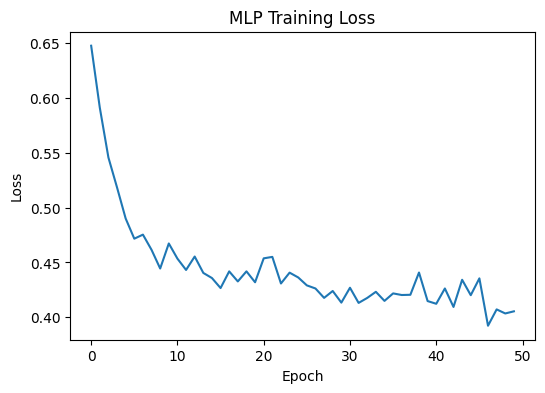

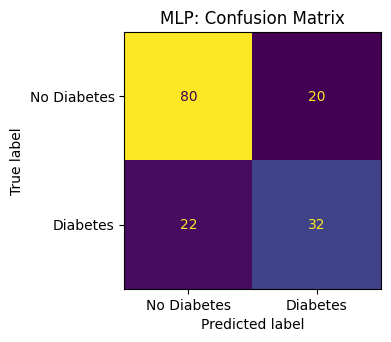

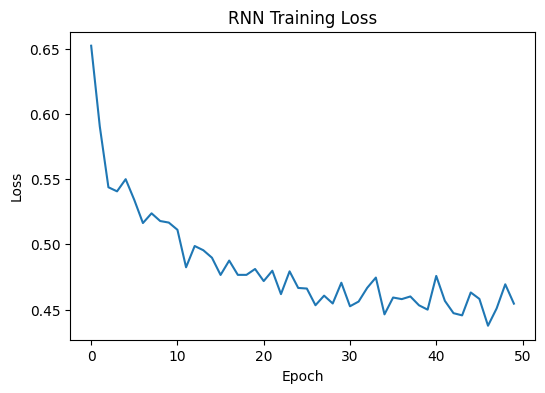

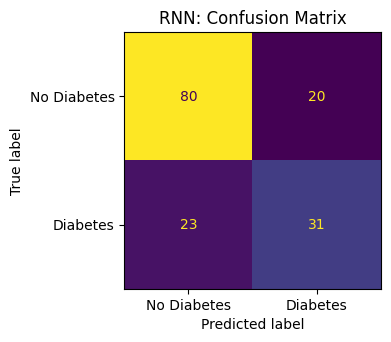

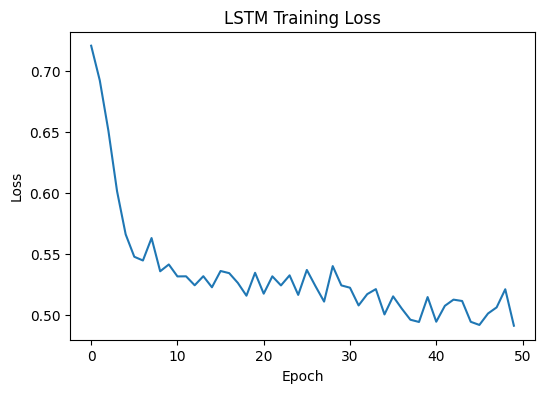

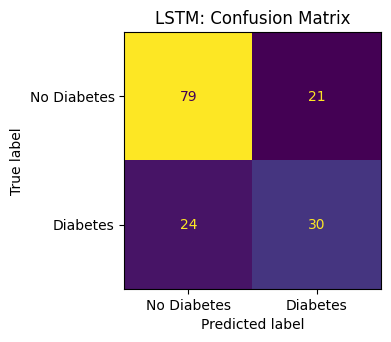

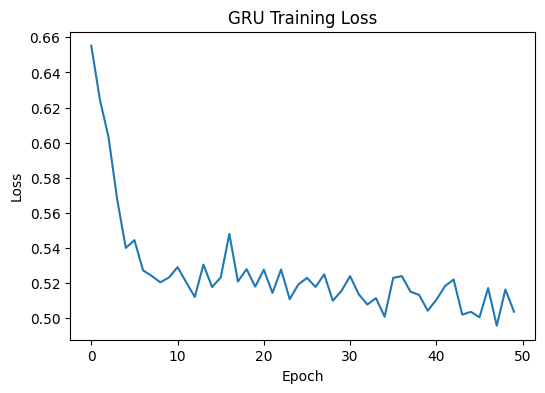

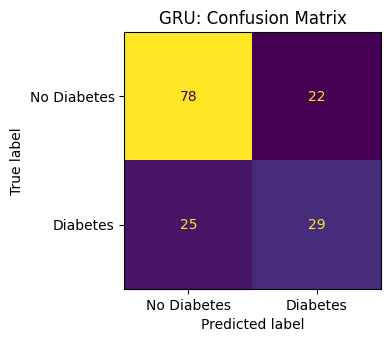

In [11]:
# Initialise a list to store evaluation results for all models
results = []

# Define a dictionary of models to be trained and evaluated
# Each entry contains:
# (model instance, training DataLoader, test input tensor)
models = {
    "MLP": (MLP(), mlp_train_loader, X_test_mlp),
    "RNN": (RNNModel(), seq_train_loader, X_test_seq),
    "LSTM": (LSTMModel(), seq_train_loader, X_test_seq),
    "GRU": (GRUModel(), seq_train_loader, X_test_seq)
}

# Iterate over all models for training, evaluation, and visualisation
for name, (model, loader, X_eval) in models.items():

    # Train the model and retrieve training loss history and training time
    losses, train_time = train_model(model, loader)

    # Evaluate the trained model on the test set
    metrics = evaluate_model(model, X_eval, y_test)

    # Add model identifier to the metrics dictionary
    metrics["Model"] = name

    # Record total training time in seconds (rounded for readability)
    metrics["Training Time (s)"] = round(train_time, 2)

    # Append the results for later comparison across models
    results.append(metrics)

    # Plot training loss curve for the current model
    plt.figure(figsize=(6, 4))

    # Loss decreases across epochs, indicating learning progress
    plt.plot(losses)

    # Set plot title indicating which model is being visualised
    plt.title(f"{name} Training Loss")

    # Label x-axis as training iterations over epochs
    plt.xlabel("Epoch")

    # Label y-axis as computed loss value
    plt.ylabel("Loss")

    # Display the plot
    plt.show()

     # Plot confusion matrix for this model right after the loss curve
    plot_confusion_matrix(model, X_eval, y_test, name)

### Section 11: Result Analysis of all Models

> Code for results analyses

In [12]:
# Create a pandas DataFrame from the list of evaluation results
# Each entry in `results` corresponds to one model (MLP, RNN, LSTM, GRU)
results_df = pd.DataFrame(results)

# Reorder columns for clearer comparison and reporting consistency
# This ensures metrics are presented in a standard evaluation order
results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "Training Time (s)"
    ]
]

# Sort models by Accuracy in descending order
# This ranks models from best to worst based on predictive performance
results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training Time (s)
0,MLP,0.727273,0.615385,0.592593,0.603774,0.818889,1.67
1,RNN,0.720779,0.607843,0.574074,0.590476,0.796852,2.23
2,LSTM,0.707792,0.588235,0.555556,0.571429,0.743519,2.70
3,GRU,0.694805,0.568627,0.537037,0.552381,0.737963,4.53


## Reflection Questions

1. Which model achieved the highest accuracy?
>MLP has the highest accuracy score
2. What assumptions do recurrent models make about feature ordering?
>Recurrent models assume that the input features are arranged as a sequence and that the order of the inputs carries meaningful information. They are modeled to learn dependencies between earlier and later elements in the sequence.
3. Did the recurrent models outperform the MLP? Justify your answer.
>No. recurrent models did not outperform the MLP model. ----
4. Why might an LSTM not significantly outperform an MLP on tabular data?
>LSTM is specifically designed to capture long-term time-series or sequential data. Basically the tabular data has independent features without any order.
5. When would RNNs, LSTMs, and GRUs be more appropriate?
>Time-series forcasting
>Natural language processing
>Sequential Data
6. How would the results change if the dataset contained genuine temporal information?
>If the data really had time-based patterns, the recurrent models would likely perform better. They would be able to learn dependencies across time, which is exactly what they are designed for.